# Getaround - Analayse

## Objectifs

- Comprendre les retards et leurs impacts

In [4]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Lecture des fichiers

print("Loading dataset...")

__file__ = os.path.abspath("EDA.ipynb")  # Simuler __file__ dans un notebook

# Définir le chemin absolu du modèle
dataset_path = os.path.join(os.path.dirname(__file__), '..', 'data', 'get_around_delay_analysis.xlsx') 
dataset_path = os.path.normpath(dataset_path)
# os.path.dirname(__file__) permet de partir du dossier où se trouve app.py.
# .. remonte d’un niveau pour atteindre la racine du projet.

dataset = pd.read_excel(dataset_path, index_col=0)


#dataset_price = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/08.Déploiement/data/get_around_pricing_project.csv", index_col=0)
print("...Done.")

Loading dataset...
...Done.


## Analye descriptive

In [8]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes (=rental_id) : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de véhicules : {}".format(dataset['car_id'].nunique()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes (=rental_id) : 21310
Nombre de colonnes : 6
Nombre de véhicules : 8143
Aperçu du dataset : 


,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
rental_id,,,,,,
505000,363965,mobile,canceled,NaN,NaN,NaN
507750,269550,mobile,ended,-81.0,NaN,NaN
508131,359049,connect,ended,70.0,NaN,NaN
508865,299063,connect,canceled,NaN,NaN,NaN
511440,313932,mobile,ended,NaN,NaN,NaN


Types de données/colonnes : 


car_id                                          int64
checkin_type                                   object
state                                          object
delay_at_checkout_in_minutes                  float64
previous_ended_rental_id                      float64
time_delta_with_previous_rental_in_minutes    float64
dtype: object

In [9]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])

# CONVERSION VALEURS NUMERIQUES
dataset['delay_at_checkout_in_minutes'] = pd.to_numeric(dataset['delay_at_checkout_in_minutes'], errors='coerce')
dataset['time_delta_with_previous_rental_in_minutes'] = pd.to_numeric(dataset['time_delta_with_previous_rental_in_minutes'], errors='coerce')




 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
delay_at_checkout_in_minutes,4964,23.29
previous_ended_rental_id,19469,91.36
time_delta_with_previous_rental_in_minutes,19469,91.36


In [10]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.00,21310,21310,16346.00,1841.00,1841.00
unique,NaN,2,2,NaN,NaN,NaN
top,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,17003,18045,NaN,NaN,NaN
mean,350030.60,NaN,NaN,59.70,550127.41,279.29
std,58206.25,NaN,NaN,1002.56,13184.02,254.59
min,159250.00,NaN,NaN,-22433.00,505628.00,0.00
25%,317639.00,NaN,NaN,-36.00,540896.00,60.00
50%,368717.00,NaN,NaN,9.00,550567.00,180.00
75%,394928.00,NaN,NaN,67.00,560823.00,540.00


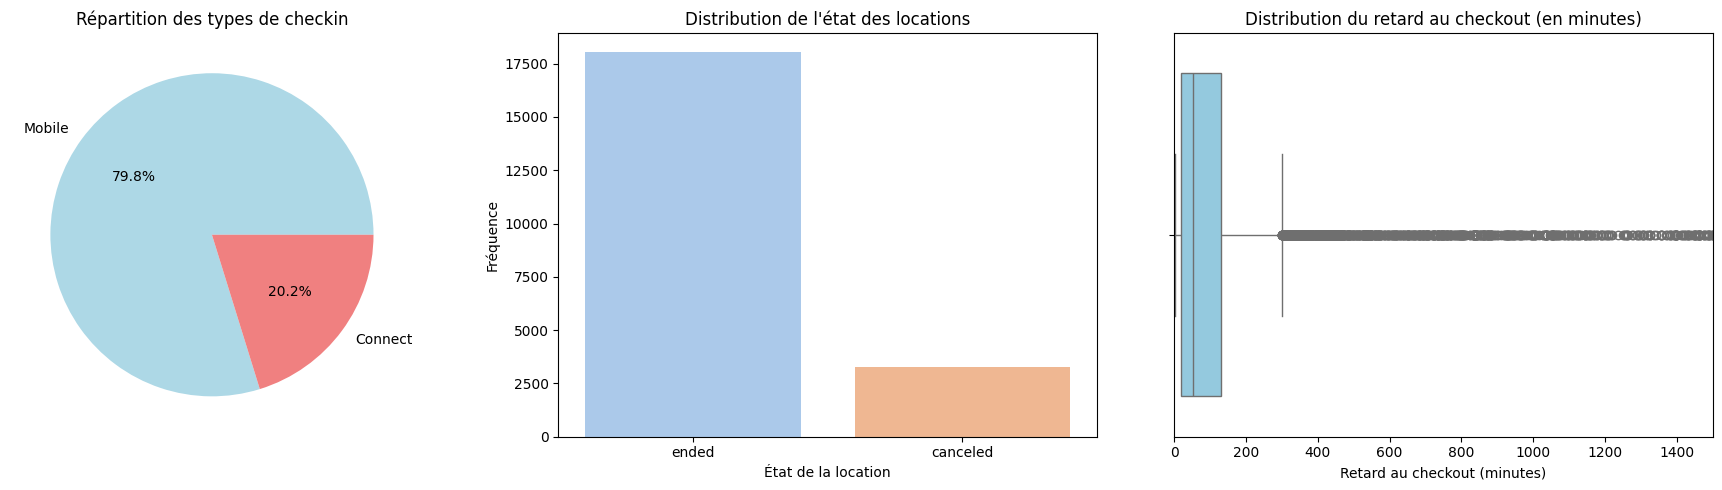

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Variable "checkin_type"
checkin_type_counts = dataset['checkin_type'].value_counts()
axes[0].pie(checkin_type_counts.values, labels=['Mobile', 'Connect'], autopct='%1.1f%%',
            colors=['lightblue', 'lightcoral'])
axes[0].set_title('Répartition des types de checkin')

# Variable "state"
sns.countplot(x='state', data=dataset, ax=axes[1], palette='pastel', order=dataset['state'].value_counts().index)
axes[1].set_title("Distribution de l'état des locations", fontsize=12)
axes[1].set_xlabel("État de la location")
axes[1].set_ylabel("Fréquence")

# Variable "delay_at_checkout_in_minutes"
sns.boxplot(x=dataset[dataset['delay_at_checkout_in_minutes'] > 0]['delay_at_checkout_in_minutes'],color='skyblue')
axes[2].set_title("Distribution du retard au checkout (en minutes)", fontsize=12)
axes[2].set_xlabel("Retard au checkout (minutes)")
axes[2].set_xlim(0, 1500)  # pas de découpe des valeurs extrêmes

# Ajustement pour que les éléments ne se chevauchent pas
plt.tight_layout()
plt.show()

In [12]:
# Suppression des lignes avec valeurs manquantes dans les colonnes clés
dataset = dataset.dropna(subset=['delay_at_checkout_in_minutes']).copy()

# ========================
# Statistiques par type de contrat
# ========================
stats_by_type = (
    dataset[dataset['delay_at_checkout_in_minutes'] > 0]
    .groupby('checkin_type')['delay_at_checkout_in_minutes']
    .agg([
        ('Retard moyen (min)', 'mean'),
        ('Retard médian (min)', 'median'),
        ('90e percentile (min)', lambda x: x.quantile(0.9))
    ])
    .reset_index()
)

# Ajout du taux de retard par type
taux_retard_by_type = (
    dataset.groupby('checkin_type')['delay_at_checkout_in_minutes']
    .apply(lambda x: (x > 0).mean())
    .reset_index(name='Taux de retard')
)

# Fusion des deux tableaux
summary = pd.merge(taux_retard_by_type, stats_by_type, on='checkin_type')

# ========================
# Calcul global
# ========================
global_row = pd.DataFrame({
    'checkin_type': ['Global'],
    'Taux de retard': [(dataset['delay_at_checkout_in_minutes'] > 0).mean()],
    'Retard moyen (min)': [dataset.loc[dataset['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes'].mean()],
    'Retard médian (min)': [dataset.loc[dataset['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes'].median()],
    '90e percentile (min)': [dataset.loc[dataset['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes'].quantile(0.9)],
    'Retard min (min)': [dataset.loc[dataset['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes'].min()],
    'Retard max (min)': [dataset.loc[dataset['delay_at_checkout_in_minutes'] > 0, 'delay_at_checkout_in_minutes'].max()]
})

# ========================
# Tableau final
# ========================
final_summary = pd.concat([global_row, summary], ignore_index=True)
final_summary['Taux de retard'] = (final_summary['Taux de retard'] * 100).round(1).astype(str) + ' %'
final_summary = final_summary.round(1)

display(final_summary)

,checkin_type,Taux de retard,Retard moyen (min),Retard médian (min),90e percentile (min),Retard min (min),Retard max (min)
0,Global,57.5 %,201.8,53.0,338.0,1.0,71084.0
1,connect,42.9 %,80.1,41.0,183.0,NaN,NaN
2,mobile,61.4 %,224.1,56.0,393.0,NaN,NaN


### Synthèse
- Type d'enregistrement : la majorité des locations passent par une rencontre physique entre le locataire et le propriétaire pour signer le contrat. Néanmoins le type de contrat ne semble pas avoir un effet significatif sur le retour de la location.

- Retard au retour : La majorité des utilisateurs rendent la voiture avec moins d’une heure de retard (entre 45 min et 1h). Cependant, une minorité de locations problématiques tirent la moyenne vers le haut (3h30)

Test sur la corrélation entre le retard au checkout et le temps séparant deux locations précédentes. Celle-ci est quasi nulle (-0.026), probablement en raison du grand nombre de valeurs manquantes (91%). Nous poursuivons donc l’analyse avec une approche de simulation pour mesurer l’effet de différents seuils de tampon.

Souhait : Mettre en place une durée tampon entre deux locations afin d'éviter les conflits.

## Simulation d'un seuil entre deux locations

### Objectifs

Tester différents délais entre deux locations , et mesurer pour chacun :
- % de locations impactées (qui deviennent incompatibles)
- % de revenus perdus (proportion de locations supprimées)
- % de retards évités (locations qui auraient été en retard sans le tampon)

#### Calcul du seuil entre deux locations

##### Méthode

- Les variables `time_delta_with_previous_rental_in_minutes`, `previous_ended_rental_id` affichent 91% de valeurs manquantes.
- Si on remplace toutes les valeurs manquantes par la moyenne, on perd toute variance.
- Conséquence : augmenter le tampon n’a quasi aucun effet sur les conflits, donc score maximal → seuil = 0.

Proposition : ajouter lorsque les valeurs sont manquantes, des durées aléatoires.

- Mesurer en fonction du délai choisi un % de locations impactées et un % de revenus évités

,threshold,pct_conflict,pct_retard_evite,delta
0,0,0.00,0.00,0.00
1,15,1.39,0.83,-0.56
2,30,1.39,0.83,-0.56
3,45,4.50,2.64,-1.86
4,60,6.80,3.96,-2.84
5,90,12.48,7.21,-5.27
6,120,17.72,10.23,-7.49
7,150,23.43,13.65,-9.78
8,180,28.30,16.43,-11.87
9,210,33.41,19.52,-13.89


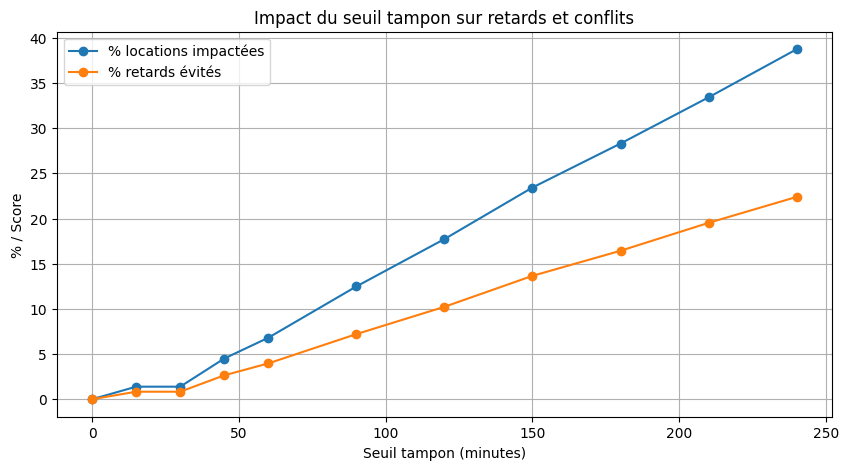

In [13]:
# copier le dataset existant
dataset_seuil=dataset.copy()

# ========================
# Simulation delta "temps" entre deux location
# ========================

# Simuler les time_delta manquants pour que la simulation ait du sens
nan_mask = dataset_seuil['time_delta_with_previous_rental_in_minutes'].isna()
dataset_seuil.loc[nan_mask, 'simulated_time_delta'] = np.random.randint(30, 600, size=nan_mask.sum())
dataset_seuil.loc[~nan_mask, 'simulated_time_delta'] = dataset_seuil.loc[~nan_mask, 'time_delta_with_previous_rental_in_minutes']

# Vérif
#print("Valeurs simulées pour time_delta_with_previous_rental_in_minutes :")
#print(dataset_seuil['simulated_time_delta'].describe())

# ========================
# Fonction pour calculer retards et conflits
# ========================
def calculate_retards_conflicts(dataset_seuil, threshold, alpha=1.0):
    """
    dataset_seuil : DataFrame avec colonnes 'simulated_time_delta' et 'delay_at_checkout_in_minutes'
    threshold : seuil tampon entre deux locations (en minutes)
    """
    dataset_seuil = dataset_seuil.copy()
    # Conflits = locations bloquées par le seuil
    dataset_seuil['conflict'] = dataset_seuil['simulated_time_delta'] < threshold
    
    # Retards évités = retards qui auraient été bloqués
    dataset_seuil['retard_evite'] = dataset_seuil['conflict'] & (dataset_seuil['delay_at_checkout_in_minutes'] > 0)
    
    pct_conflict = dataset_seuil['conflict'].mean() * 100
    pct_retard_evite = dataset_seuil['retard_evite'].mean() * 100
    
    # Score trade-off = retards évités - alpha * conflits
    score = pct_retard_evite - alpha * pct_conflict
    
    return pct_conflict, pct_retard_evite, score

# ========================
# Simulation pour plusieurs seuils
# ========================
thresholds = [0, 15, 30, 45, 60, 90, 120, 150, 180, 210, 240]
results = []

for t in thresholds:
    conflict, retard, s = calculate_retards_conflicts(dataset_seuil, t)
    results.append({'threshold': t, 'pct_conflict': conflict, 'pct_retard_evite': retard})

results_df = pd.DataFrame(results)

# Calculs de base
results_df['delta'] = results_df['pct_retard_evite'] - results_df['pct_conflict']

# Affichage du tableau récapitulatif
cols_to_display = ['threshold', 'pct_conflict', 'pct_retard_evite', 'delta']
display(results_df[cols_to_display].round(2))

# ========================
# Visualisation
# ========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results_df['threshold'], results_df['pct_conflict'], label='% locations impactées', marker='o')
plt.plot(results_df['threshold'], results_df['pct_retard_evite'], label='% retards évités', marker='o')
plt.xlabel("Seuil tampon (minutes)")
plt.ylabel("% / Score")
plt.title("Impact du seuil tampon sur retards et conflits")
plt.legend()
plt.grid(True)
plt.show()


##### Interprétation

En appliquant un tampon d’une heure entre deux locations :
- Environ 4 % des retards sont évités.
- 6.9 % des locations deviendraient incompatibles (donc autant de revenus potentiels perdus).

Cela correspond à un compromis modéré : on réduit légèrement le risque de retard sans impacter de façon excessive la disponibilité des véhicules.
Au-delà de ce seuil, le coût en revenu augmente plus vite que le gain sur les retards (voir score croissant mais à rendement décroissant).

Ce délai "tampon" est cohérent également cohérent au regard du retard médian observé (53 min).

##### Approche perte pour le client

- Calcul d'une fonction de coût afin d'identifier la perte pour le client
  - Etape 1 - calcul du revenu moyen par location
    - Revenu_moyen = revenu journalier mpyen x durée moyenne location en jours
  - Etape 2 - calcul d'un coût de retard évite. Ce coût correspond à du temps perdu qu'on pourrait louer. Un retard d'une heure sur une location de 4 h coûte environ 1/4 du revenu moyen
    - Coût_retard = revenu moyen x (retard moyen/durée moyenne)
  - Etape 3 - Score monétaire basé sur les taux (%) 
    - Score/location = Coût_retard x % retard évité - Revenu_moyen x % conflit 

In [14]:
# Lecture des fichiers
# Lecture des fichiers
print("Loading dataset...")

__file__ = os.path.abspath("ML.ipynb")  # Simuler __file__ dans un notebook

# Définir le chemin absolu du modèle
dataset_path = os.path.join(os.path.dirname(__file__), '..', 'data', 'get_around_pricing_project.csv') 
dataset_path = os.path.normpath(dataset_path)
# os.path.dirname(__file__) permet de partir du dossier où se trouve app.py.
# .. remonte d’un niveau pour atteindre la racine du projet.

dataset_price = pd.read_csv(dataset_path, index_col=0)


#dataset_price = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/08.Déploiement/data/get_around_pricing_project.csv", index_col=0)
print("...Done.")

Loading dataset...
...Done.


In [15]:
# Hypothèses
revenu_journalier_moyen = dataset_price['rental_price_per_day'].mean()  # € / jour
duree_moyenne_min = dataset_seuil['simulated_time_delta'].mean()  # convertir en minutes
duree_moyenne_jours = duree_moyenne_min / 24 / 60
retard_moyen_min = dataset_seuil['delay_at_checkout_in_minutes'].mean()  # moyenne observée


R_avg = (revenu_journalier_moyen) * duree_moyenne_jours
C_delay = R_avg * (retard_moyen_min / duree_moyenne_min)

# Calcul du score monétaire
results_df["score_monetary"] = (
    C_delay * (results_df["pct_retard_evite"] / 100)
    - R_avg * (results_df["pct_conflict"] / 100)
)

# Classement
#print(results_df[["threshold", "pct_conflict", "pct_retard_evite", "score_monetary"]])

# Nombre total de locations (ou nombre de lignes dans ton dataset)
total_locations = dataset_seuil.shape[0]

# Calcul du gain/perte net total par seuil
results_df["total_score_euros"] = results_df["score_monetary"] * total_locations

# Affichage
display(round(results_df[["threshold", "pct_conflict", "pct_retard_evite", "score_monetary", "total_score_euros"]], 2))


,threshold,pct_conflict,pct_retard_evite,score_monetary,total_score_euros
0,0,0.00,0.00,0.00,0.00
1,15,1.39,0.83,-0.32,-5257.91
2,30,1.39,0.83,-0.32,-5257.91
3,45,4.50,2.64,-1.05,-17092.66
4,60,6.80,3.96,-1.58,-25848.38
5,90,12.48,7.21,-2.90,-47473.85
6,120,17.72,10.23,-4.12,-67421.92
7,150,23.43,13.65,-5.45,-89027.49
8,180,28.30,16.43,-6.58,-107580.00
9,210,33.41,19.52,-7.76,-126923.15


##### Interprétation

Pour un seuil à 60 min entre deux location:
- % conflits = 6.8 % des locations seraient perdues.
- % retards évités = 4.0 %.

Score = -1.60 €

En moyenne, ajouter 1h de délai entre deux locations ferait perdre 1,60 € par location, une fois qu’on a pris en compte : 
- le gain lié aux retards évités (moins de décalages, meilleure rotation)
- la perte de revenu liée aux locations bloquées par le tampon

Donc :
- un score négatif = mesure économiquement non rentable (coût > gain)
- un score positif = rentable, le gain en retards évités compense la perte de revenu

L’impact économique du tampon augmente plus vite côté “perte” (revenu bloqué) que côté “gain” (retards évités).

### Conclusion

Selon la simulation, l’ajout d’un délai entre deux locations entraîne une perte de revenu croissante.
À 1 heure de tampon, le revenu moyen par location diminuerait d’environ 1.44 €, tandis qu’à 2 heures, la perte atteindrait près de 3.0 €.
Ces montants restent faibles individuellement, mais représentent une perte significative à l’échelle du parc de véhicules.

Aucun seuil testé n’est économiquement avantageux.
Pour aller plus loin, il faudrait prendre en compte les coûts indirects.